In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

from datasets import load_dataset, Audio
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

import io
import soundfile as sf

print("EXP-02: Noise Robustness")

In [2]:
dataset = load_dataset(
    "guynich/librispeech_asr_test_vad",
    split="test.clean",
    streaming=True
)

dataset = dataset.cast_column(
    "audio",
    Audio(decode=False)
)

sample = next(iter(dataset))

audio_data = sample["audio"]

if audio_data["bytes"] is not None:
    y, sr = sf.read(io.BytesIO(audio_data["bytes"]))
else:
    y, sr = sf.read(audio_data["path"])

if y.ndim > 1:
    y = y.mean(axis=1)

reference = np.asarray(sample["speech"], dtype=int)
confidence = np.asarray(sample["confidence"], dtype=int)

print("Dosya:", sample["file"])
print("Örnekleme frekansı:", sr)
print("Ses süresi:", round(len(y) / sr, 3), "saniye")

Dosya: 6930-75918-0000.flac
Örnekleme frekansı: 16000
Ses süresi: 3.505 saniye


In [3]:
def add_noise(signal, snr_db, seed=42):

    rng = np.random.default_rng(seed)

    # Rastgele beyaz Gauss gürültüsü
    noise = rng.normal(0, 1, len(signal))

    # Sinyal ve gürültü güçleri
    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)

    # Hedef SNR'ye göre gürültüyü ölçekle
    target_noise_power = signal_power / (10 ** (snr_db / 10))

    noise = noise * np.sqrt(
        target_noise_power / noise_power
    )

    noisy_signal = signal + noise

    return noisy_signal

In [4]:
snr_levels = [20, 10, 0]

noisy_signals = {}

for snr in snr_levels:

    noisy_signals[snr] = add_noise(
        y,
        snr_db=snr
    )

    print(f"{snr} dB SNR için ses oluşturuldu.")

print("Bütün gürültülü kayıtlar hazır.")

20 dB SNR için ses oluşturuldu.
10 dB SNR için ses oluşturuldu.
0 dB SNR için ses oluşturuldu.
Bütün gürültülü kayıtlar hazır.


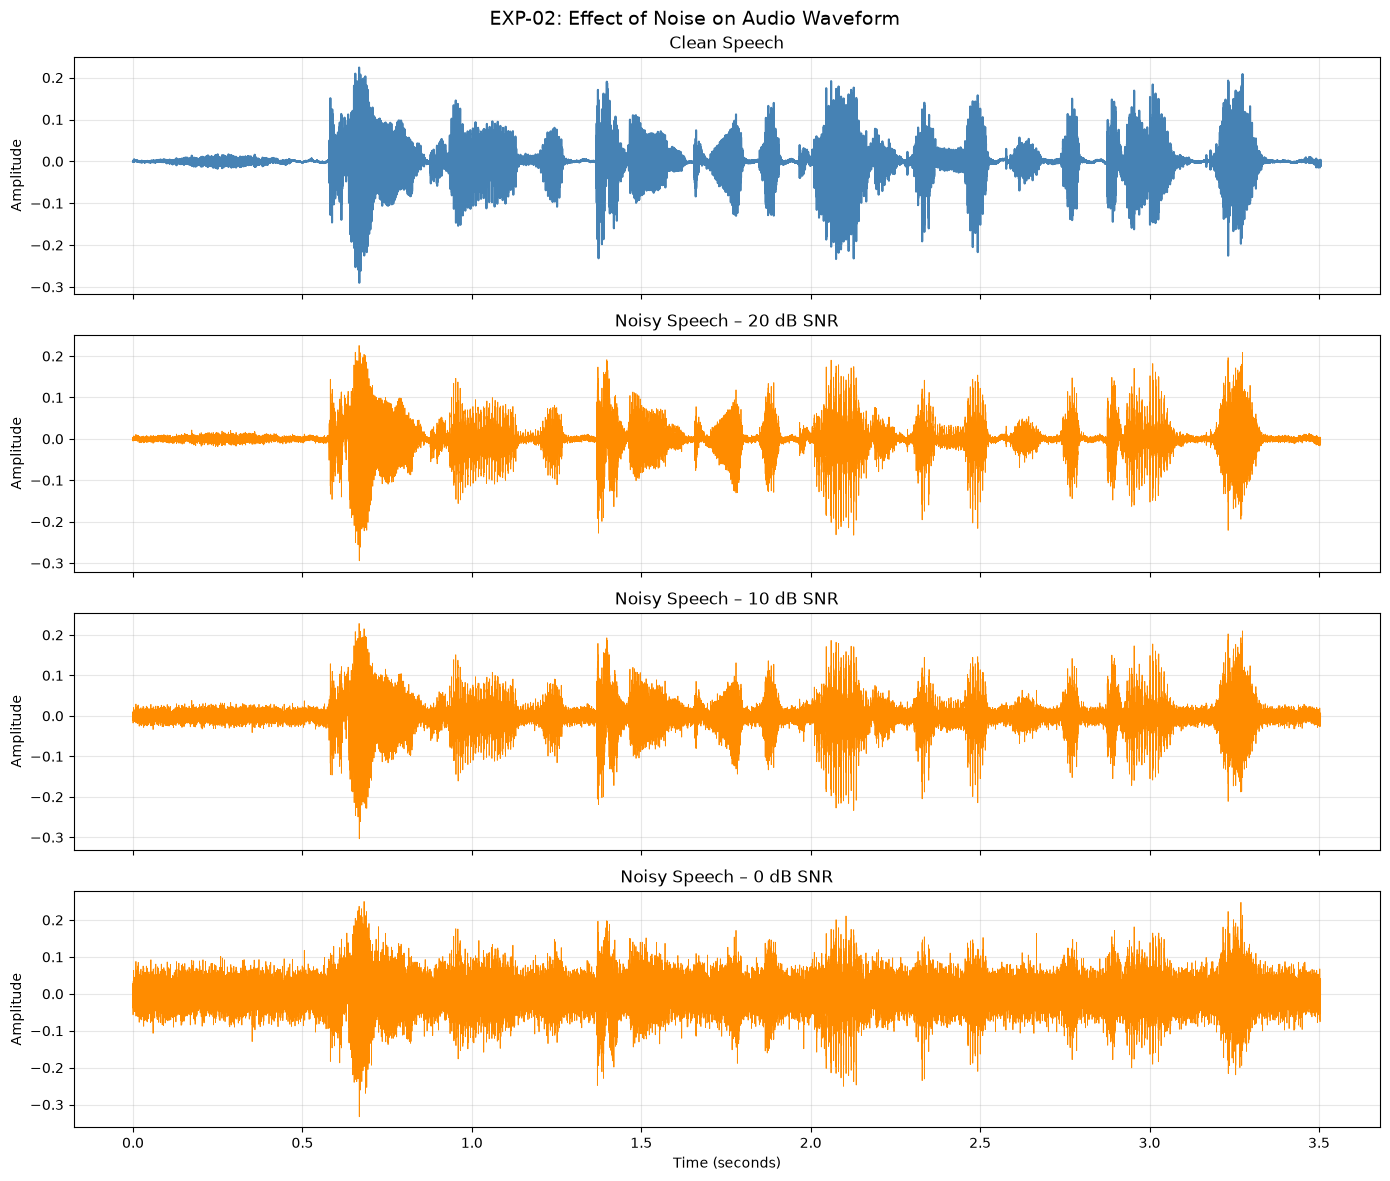

In [5]:
time = np.arange(len(y)) / sr

fig, axes = plt.subplots(
    4, 1,
    figsize=(14, 12),
    sharex=True
)

axes[0].plot(
    time,
    y,
    color="steelblue"
)

axes[0].set_title("Clean Speech")

for ax, snr in zip(axes[1:], snr_levels):

    ax.plot(
        time,
        noisy_signals[snr],
        color="darkorange",
        linewidth=0.6
    )

    ax.set_title(f"Noisy Speech – {snr} dB SNR")

for ax in axes:
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

plt.suptitle(
    "EXP-02: Effect of Noise on Audio Waveform",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [6]:
frame_ms = 25
hop_ms = 10

frame_length = int(sr * frame_ms / 1000)
hop_length = int(sr * hop_ms / 1000)

signals = {
    "Clean": y,
    "20 dB": noisy_signals[20],
    "10 dB": noisy_signals[10],
    "0 dB": noisy_signals[0]
}

rms_results = {}

for name, signal in signals.items():

    rms_results[name] = librosa.feature.rms(
        y=signal,
        frame_length=frame_length,
        hop_length=hop_length,
        center=False
    )[0]

rms_times = (
    np.arange(len(rms_results["Clean"])) * hop_length
    + frame_length / 2
) / sr

print("Bütün kayıtların RMS değerleri hesaplandı.")

Bütün kayıtların RMS değerleri hesaplandı.


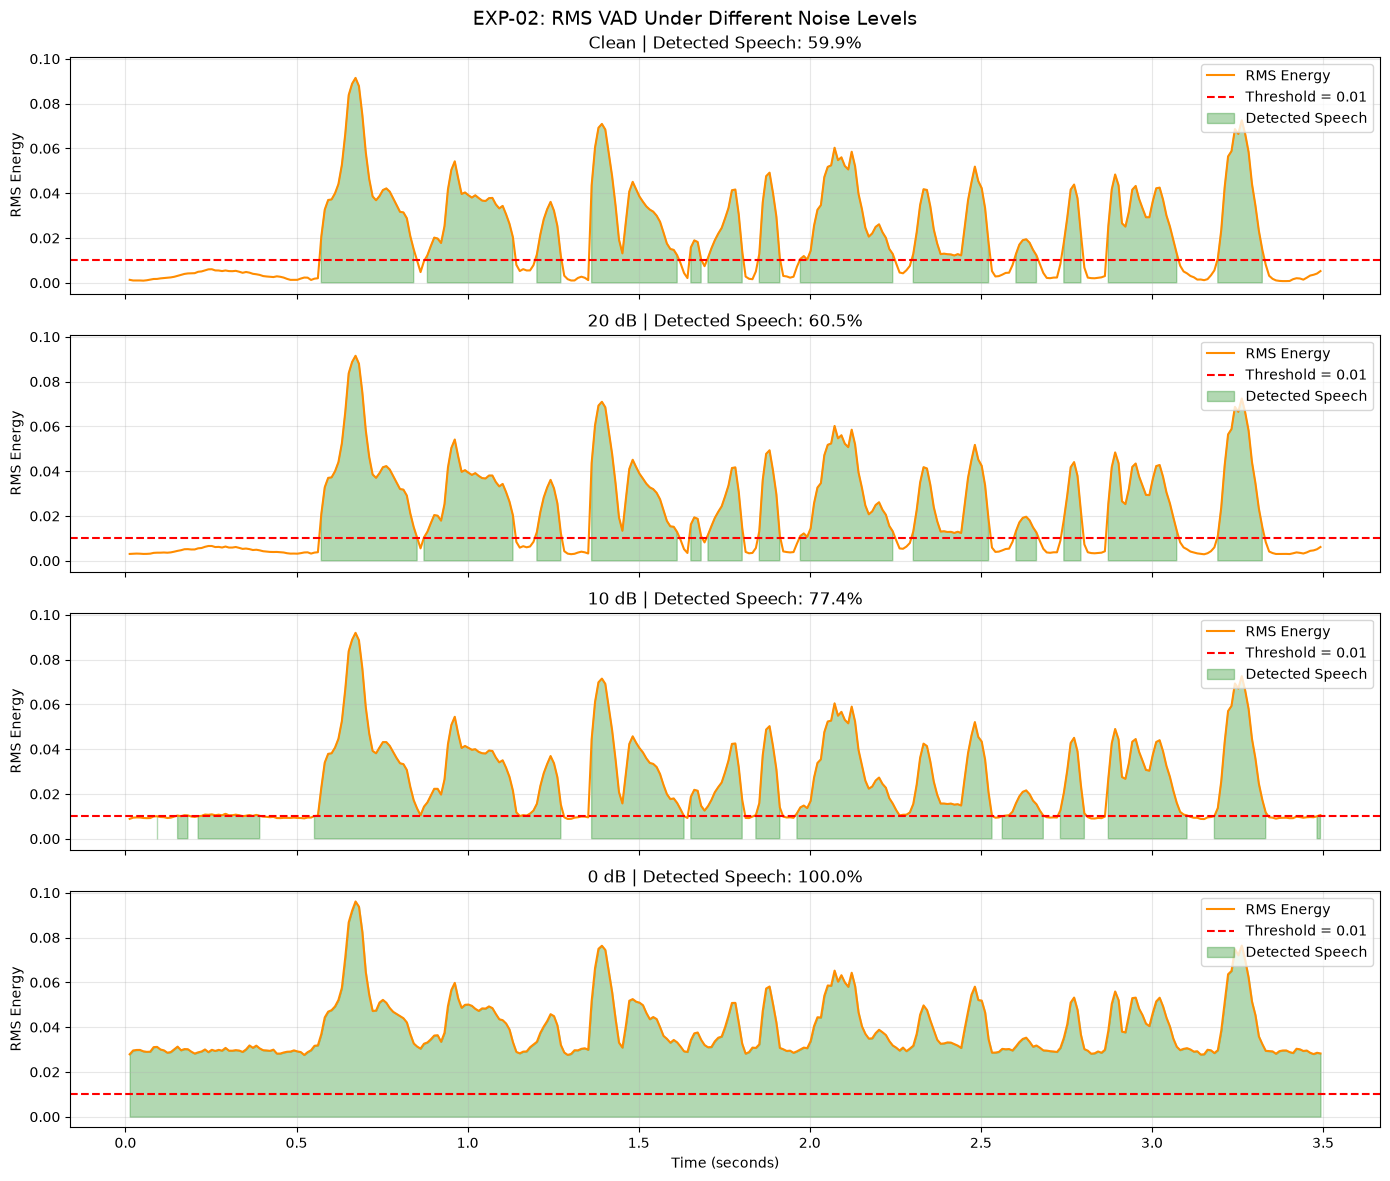

In [7]:
threshold = 0.01

fig, axes = plt.subplots(
    4, 1,
    figsize=(14, 12),
    sharex=True,
    sharey=True
)

for ax, (name, rms_values) in zip(
    axes, rms_results.items()
):

    prediction = (rms_values > threshold).astype(int)

    ax.plot(
        rms_times,
        rms_values,
        color="darkorange",
        label="RMS Energy"
    )

    ax.axhline(
        threshold,
        color="red",
        linestyle="--",
        label="Threshold = 0.01"
    )

    ax.fill_between(
        rms_times,
        0,
        rms_values,
        where=prediction == 1,
        color="green",
        alpha=0.3,
        label="Detected Speech"
    )

    speech_ratio = prediction.mean() * 100

    ax.set_title(
        f"{name} | Detected Speech: {speech_ratio:.1f}%"
    )

    ax.set_ylabel("RMS Energy")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

plt.suptitle(
    "EXP-02: RMS VAD Under Different Noise Levels",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [8]:
frame_ms = 25
hop_ms = 10

frame_length = int(sr * frame_ms / 1000)
hop_length = int(sr * hop_ms / 1000)

signals = {
    "Clean": y,
    "20 dB": noisy_signals[20],
    "10 dB": noisy_signals[10],
    "0 dB": noisy_signals[0]
}

rms_results = {}

for name, signal in signals.items():

    rms_results[name] = librosa.feature.rms(
        y=signal,
        frame_length=frame_length,
        hop_length=hop_length,
        center=False
    )[0]

rms_times = (
    np.arange(len(rms_results["Clean"])) * hop_length
    + frame_length / 2
) / sr

print("Bütün kayıtların RMS değerleri hesaplandı.")

Bütün kayıtların RMS değerleri hesaplandı.


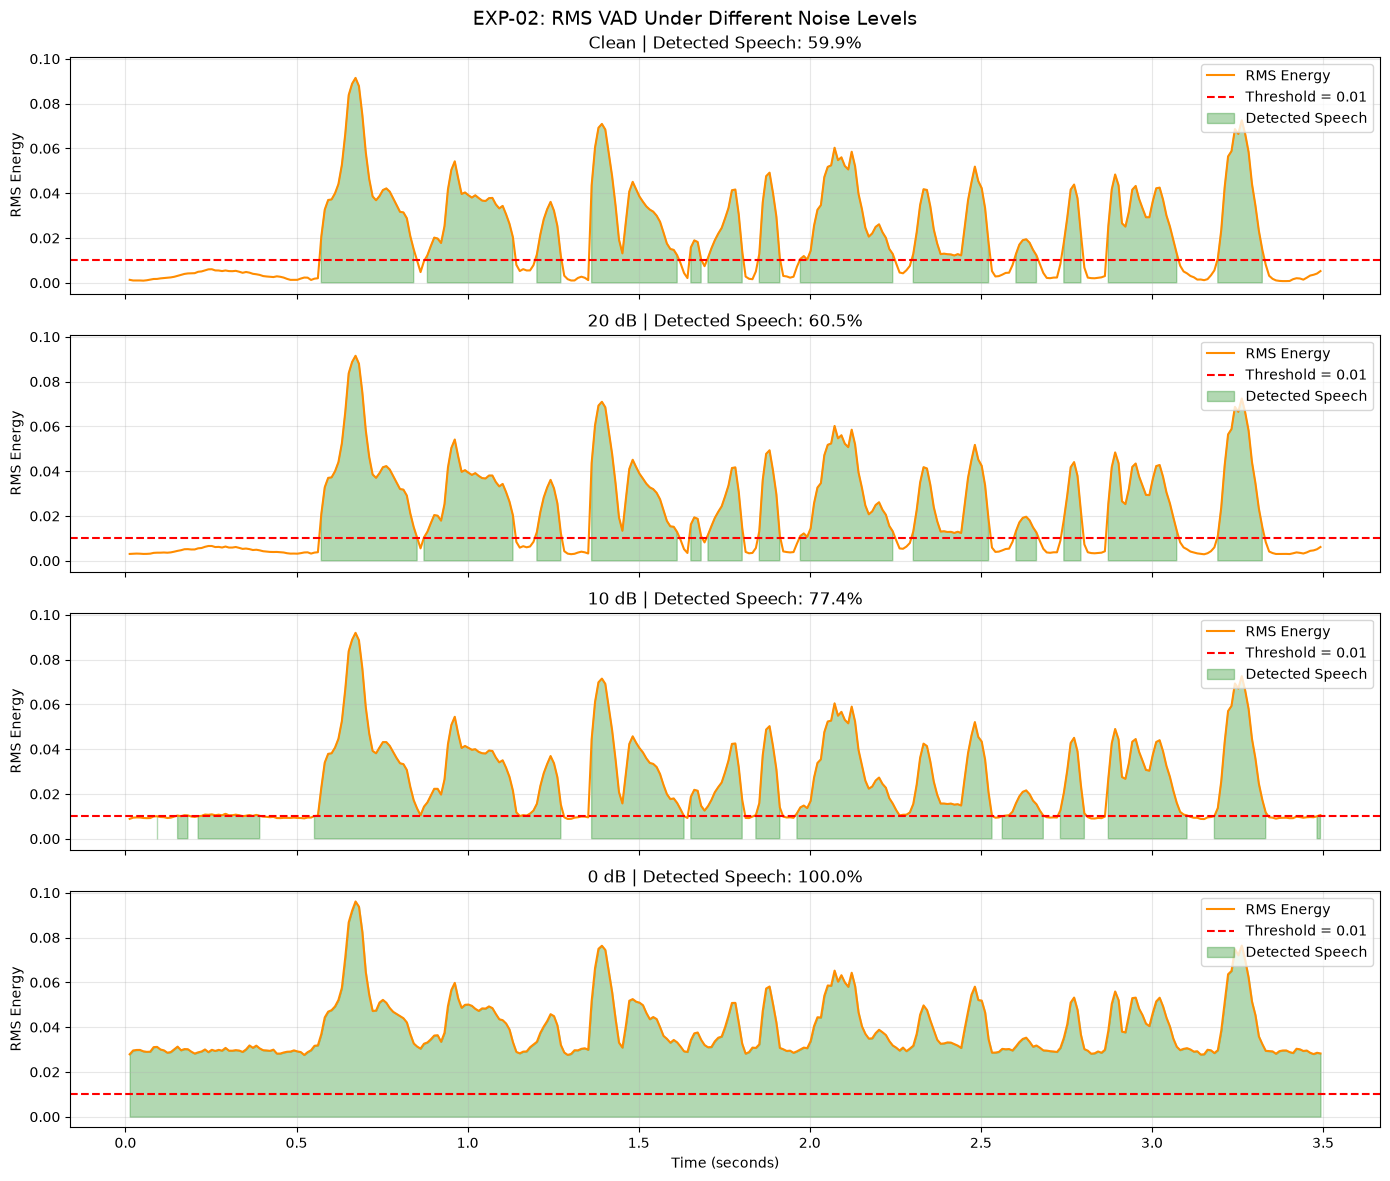

In [9]:
threshold = 0.01

fig, axes = plt.subplots(
    4, 1,
    figsize=(14, 12),
    sharex=True,
    sharey=True
)

for ax, (name, rms_values) in zip(
    axes, rms_results.items()
):

    prediction = (rms_values > threshold).astype(int)

    ax.plot(
        rms_times,
        rms_values,
        color="darkorange",
        label="RMS Energy"
    )

    ax.axhline(
        threshold,
        color="red",
        linestyle="--",
        label="Threshold = 0.01"
    )

    ax.fill_between(
        rms_times,
        0,
        rms_values,
        where=prediction == 1,
        color="green",
        alpha=0.3,
        label="Detected Speech"
    )

    speech_ratio = prediction.mean() * 100

    ax.set_title(
        f"{name} | Detected Speech: {speech_ratio:.1f}%"
    )

    ax.set_ylabel("RMS Energy")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

plt.suptitle(
    "EXP-02: RMS VAD Under Different Noise Levels",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [10]:
# Referans etiketleri yaklaşık zaman eksenine yerleştir
duration = len(y) / sr

reference_times = (
    np.arange(len(reference)) + 0.5
) * duration / len(reference)

# En yakın RMS frame'ini bul
indices = np.abs(
    rms_times[:, None] - reference_times[None, :]
).argmin(axis=0)

# Yalnızca güvenilir referans etiketlerini kullan
valid = confidence == 1

threshold = 0.01

metrics_results = {}

for name, rms_values in rms_results.items():

    prediction = (rms_values > threshold).astype(int)

    aligned_prediction = prediction[indices]

    y_true = reference[valid]
    y_pred = aligned_prediction[valid]

    precision = precision_score(
        y_true, y_pred, zero_division=0
    )

    recall = recall_score(
        y_true, y_pred, zero_division=0
    )

    f1 = f1_score(
        y_true, y_pred, zero_division=0
    )

    accuracy = accuracy_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    metrics_results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Accuracy": accuracy,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }

    print(f"\n{name}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
    


Clean
Precision: 1.000
Recall:    0.805
F1-score:  0.892
Accuracy:  0.842
TP: 66 | TN: 19 | FP: 0 | FN: 16

20 dB
Precision: 1.000
Recall:    0.817
F1-score:  0.899
Accuracy:  0.851
TP: 67 | TN: 19 | FP: 0 | FN: 15

10 dB
Precision: 0.892
Recall:    0.902
F1-score:  0.897
Accuracy:  0.832
TP: 74 | TN: 10 | FP: 9 | FN: 8

0 dB
Precision: 0.812
Recall:    1.000
F1-score:  0.896
Accuracy:  0.812
TP: 82 | TN: 0 | FP: 19 | FN: 0


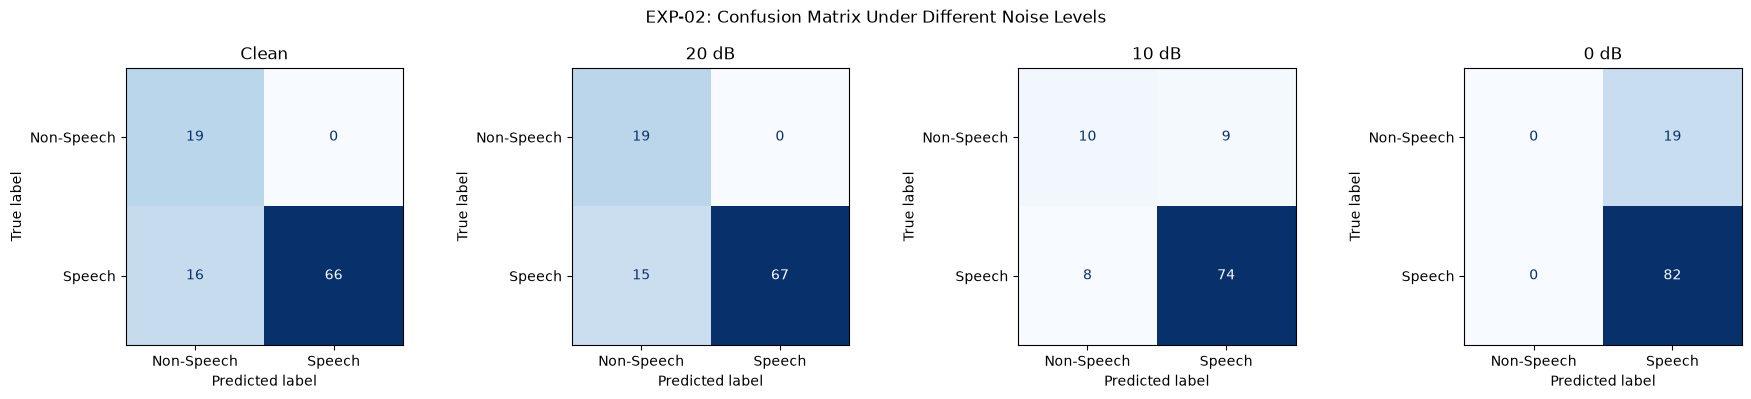

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, result) in zip(
    axes,
    metrics_results.items()
):

    cm = np.array([
        [result["TN"], result["FP"]],
        [result["FN"], result["TP"]]
    ])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Speech", "Speech"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)

plt.suptitle(
    "EXP-02: Confusion Matrix Under Different Noise Levels"
)

plt.tight_layout()
plt.show()